Ödev 2 için sonuçlar

Bu notebook, hog öznitelikleri ve pytorch mlp model kullanılarak yapılan nesne tespiti çalışmasının validation ve test sonuçlarını göstermektedir.
Model, her görüntüyü 9 pencereye ayırır ve her pencere için background veya object tahmni yapar



In [18]:
from pathlib import Path 
import numpy as np
import torch

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from IPython.display import Image, display

import sys
sys.path.append("../src")
from config import FEATURE_DIR, BEST_MODEL_PATH, RESULT_DIR
from mlp_model import HOGMLP

In [20]:
# BURASI EN İYİ MODELİ YÜKLEMEK İÇİN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)

print("Kullanılan cihaz:", device)
print("En iyi hyperparametreler:")
print(checkpoint["best_params"])
print("En iyi validaiton F1:", checkpoint["best_val_f1"])

Kullanılan cihaz: cuda
En iyi hyperparametreler:
{'hiddenSize': 512, 'hiddenLayers': 2, 'learningRate': 0.0001, 'batchSize': 128, 'dropoutRate': 0.5, 'useBatchNorm': True, 'patience': 15, 'maxEpochs': 80}
En iyi validaiton F1: 0.5377216605716046


In [21]:
# BURASI TEST VERİSİNİ YÜKLEMEK İÇİN

testData = np.load(FEATURE_DIR / "test_features.npz")

test_features = testData["features"]
test_labels = testData["labels"]

print("Test feature boyutu:" , test_features.shape)
print("Test label boyutu:", test_labels.shape)

Test feature boyutu: (10890, 7560)
Test label boyutu: (10890,)


In [23]:
# BURDA MODELİ TEKRAR OLUŞTURUP TAHMŞNLERİ ALIYORUZ

scaler = checkpoint["scaler"]

test_features_scaled = scaler.transform(test_features)

test_tensor = torch.tensor(test_features_scaled, dtype=torch.float32).to(device)

model = HOGMLP(inputSize=checkpoint["input_size"], numClasses=checkpoint["num_classes"], hiddenSize=checkpoint["best_params"]["hiddenSize"], hiddenLayers=checkpoint["best_params"]["hiddenLayers"], useBatchNorm=checkpoint["best_params"]["useBatchNorm"], dropoutRate=checkpoint["best_params"]["dropoutRate"]).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    outputs =  model(test_tensor)
    predictions = torch.argmax(outputs, dim=1).cpu().numpy()


print("Tahminler oluşturuldu")
print("Toplam tahmin sayısı:", len(predictions))



Tahminler oluşturuldu
Toplam tahmin sayısı: 10890


In [38]:
# BURASI TEST METRİKLERİNİN GÖSTERİLMESİ İÇİN

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average="macro", zero_division=0)

precision = precision_score(test_labels, predictions, average="macro", zero_division=0)

recall = recall_score(test_labels, predictions, average="macro", zero_division=0)

f1 = f1_score(test_labels, predictions, average="macro", zero_division=0)

print("Test sonuçları")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 score : {f1:.4f}")

Test sonuçları
----------------------------------------
Accuracy : 0.5305
Precision : 0.2574
Recall : 0.3403
F1 score : 0.2481


In [39]:
confMatrix = confusion_matrix(test_labels, predictions)

print("Karmaşıklık Matrisi")
print(confMatrix)

Karmaşıklık Matrisi
[[ 171  156   47    0    0]
 [1148 5292 1238  776  813]
 [ 175  167  121    6   70]
 [  42   47   15   19    3]
 [  51   95  247   17  174]]


In [40]:
print("Classification Report")
print(classification_report(test_labels, predictions, zero_division=0))

Classification Report
              precision    recall  f1-score   support

           0       0.11      0.46      0.17       374
           1       0.92      0.57      0.70      9267
           2       0.07      0.22      0.11       539
           3       0.02      0.15      0.04       126
           4       0.16      0.30      0.21       584

    accuracy                           0.53     10890
   macro avg       0.26      0.34      0.25     10890
weighted avg       0.80      0.53      0.62     10890



Gösterilen sonuç görseli: C:\Users\USER\Desktop\468Odev2\outputs\results\detection_052660.jpg


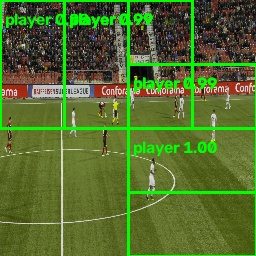

In [67]:
# BURASI ÖRNEK GÖRSEL ÜZERİNDEN GÖSTERME

resultImage = sorted(RESULT_DIR.glob("detection_*.jpg"))

if len(resultImage) > 0:
    print("Gösterilen sonuç görseli:", resultImage[0])
    display(Image(filename=str(resultImage[0])))
else:
    print("Detection görseli bulunamadı. visualize_detection.py yi çalıştırın")

Model test veri setinde her görüntünün 9 pencerisi için ayrı ayrı tahmnin üretmiştir. Karmaşıklık matrisi, background ve object bölgelerini ne kadar doğru sınıflandırıldığını göstermektedir.
Değerlendirme metrikleri ile performans değerlendirilmiştir.
Görselleştirme sonucunda modelin nesne bulunduğunu tahmin ettiği pencereler kare içine alınmıştır. Doğru kare içine alınan bölgeler modelin nesne konumlandırma başarısını, hatalı veya eksik kareler ise modelin sınırlı kaldığı durumları göstermektedir.